In [8]:
import sys
sys.path.append(r"D:\Uni\Bristol\TB3\AI\reinforcement learning\deeplearning-from-scratch-4")

import numpy as np

from common.gridworld import GridWorld

**对不同策略的TD方法在GridWorld环境上执行并比较**

由于执行流程相同，写一个函数，根据传入的类不同，会调用不同策略的td方法。可反复使用

In [ ]:
def run_gridworld_with_td(agentType):
    """td算法的执行与可视化"""
    np.random.seed(42) # 使结果可复现
    env = GridWorld()
    agent = agentType(gamma=0.9, alpha=0.01, epsilon=0.1, action_size=4)

    episodes = 10000
    for episode in range(episodes):
        state = env.reset()
        agent.reset()

        while True:
            action = agent.get_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, done) # 每次都要调用

            if done:
                # 到达目标时也要调用
                agent.update(next_state, None, None, None) 
                break
            state = next_state

    env.render_q(agent.Q)

- 同策略型TD算法

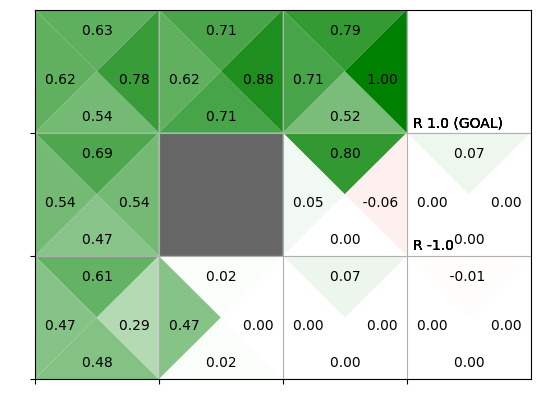

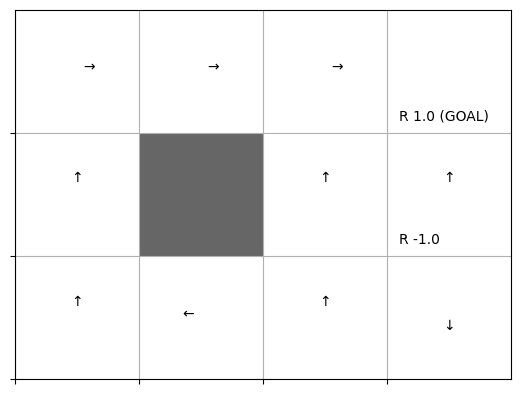

In [13]:
from sarsa import SarsaAgent

run_gridworld_with_td(SarsaAgent)

- 异策略型TD算法

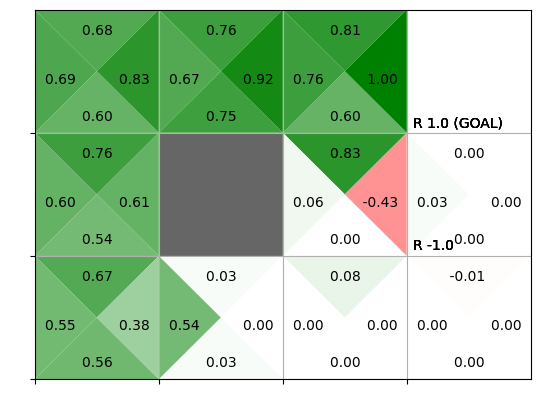

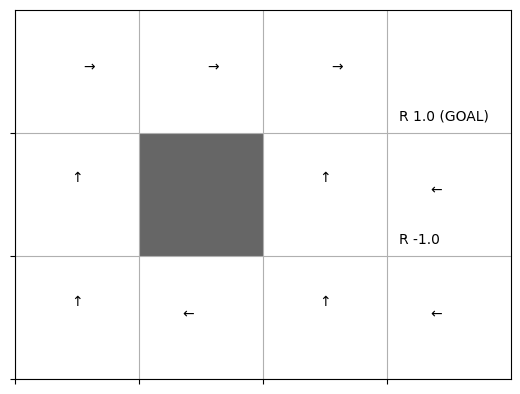

In [14]:
from sarsa_off_policy import OffPolicySarsaAgent

run_gridworld_with_td(OffPolicySarsaAgent)